In [1]:
import sys, os
# ensure parent directory is on the path so `src` package can be imported
sys.path.insert(0, os.path.abspath('../..'))

In [2]:
# configura per importare da src
import sys
sys.path.append('./src')

## CBM

### Load dataset

In [3]:
from src.utils.dataset import load_concept_data, prepare_class_concept_dataset, parse_classes, parse_concepts
import torch
import numpy as np

concepts = parse_concepts('../../AwA2_Dataset_Labels/Animals_with_Attributes2/extended_concepts.txt')
classes = parse_classes('../../AwA2_Dataset_Labels/Animals_with_Attributes2/classes.txt')
class2id = {c: idx for idx, c in enumerate(classes)}
class_concept_matrix = torch.from_numpy(np.loadtxt('../../Awa2_Dataset_Labels/Animals_with_Attributes2/extended_matrix.txt', dtype=int))
dataset, concept2id, id2concept = load_concept_data('../../AwA2_Dataset_Labels/Animals_with_Attributes2/supervisioni_gerarchia.json', concepts)
datasetClasses = prepare_class_concept_dataset(class_concept_matrix, class2id)

In [4]:
import torch
from src.BOX.model import BoxHierarchyModel

box_model = BoxHierarchyModel(num_concepts=len(concepts), dim=16)

AllenNLP not available. Registrable won't work.


In [5]:
box_model.load_state_dict(torch.load("../../AwA2_Dataset_Labels/Animals_with_Attributes2/modello_gerarchia.pth"))

<All keys matched successfully>

In [6]:
from src.utils.box import get_box_dict
box_dict = get_box_dict(box_model, id2concept)

In [8]:
from src.utils.dataset import classical_split_awa2_features
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
from src.utils.box import prepara_tensore_box

features_path = '../../AwA2_Dataset_Features/Animals_with_Attributes2/Features/ResNet101/AwA2-features.txt'
labels_path = '../../AwA2_Dataset_Features/Animals_with_Attributes2/Features/ResNet101/AwA2-labels.txt'

(X_train, y_train), (X_val, y_val), (X_test, y_test) = classical_split_awa2_features(
    features_path, labels_path, test_size=0.2, val_size=0.1, random_seed=42
)
class_concept_matrix = torch.from_numpy(np.loadtxt('../../Awa2_Dataset_Labels/Animals_with_Attributes2/extended_matrix.txt', dtype=int))

box_tensors = prepara_tensore_box(box_dict, concept2id)

BOX_DIM = 16
BATCH_SIZE = 32
EPOCHS = 6
NUM_CLASSES = len(set(y_train))
NUM_CONCEPTS = len(concept2id)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

train_dataset = TensorDataset(torch.tensor(X_train).float(), torch.tensor(y_train).long())
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)
val_dataset = TensorDataset(torch.tensor(X_val).float(), torch.tensor(y_val).long())
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, pin_memory=True)
test_dataset = TensorDataset(torch.tensor(X_test).float(), torch.tensor(y_test).long())
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, pin_memory=True)

Caricamento dei dati in corso... (potrebbe richiedere qualche secondo)
Dataset caricato correttamente: 37322 campioni con 2048 feature ciascuno.

--- Risultati dello Split Stratificato (50 Classi) ---
Training set:   26124 campioni
Validation set: 3733 campioni
Test set:       7465 campioni
Using device: cpu


In [9]:
from src.CHM.model import ConceptBottleneckClassifier
from src.CP.model import ConceptPredictor
from src.CHM.train import sequential_training
import matplotlib.pyplot as plt
from src.CHM.test import test_sequential_cbm
from src.utils.plot import plot_history, plot_test_results
import torch.nn as nn

### CBM with boxes

#### Train

In [10]:
b_cls = ConceptBottleneckClassifier(box_dim=box_tensors.size(-1), num_classes=NUM_CLASSES, num_concepts=NUM_CONCEPTS)
b_cls_optimizer = torch.optim.Adam(b_cls.parameters(), lr=0.001)
b_cls_criterion = nn.CrossEntropyLoss()

b_concept_predictor = ConceptPredictor(X_train.shape[1], num_concepts=NUM_CONCEPTS)
b_concept_optimizer = torch.optim.Adam(b_concept_predictor.parameters(), lr=0.001)
b_concept_criterion = nn.BCEWithLogitsLoss()

info = "boxes"

b_conc_history, b_cls_history = sequential_training(
    b_cls,
    b_concept_predictor,
    train_dataloader, 
    val_dataloader,
    class_concept_matrix,
    box_tensors,
    b_cls_optimizer,  
    b_concept_optimizer,
    b_cls_criterion,
    b_concept_criterion,
    EPOCHS, 
    device,
    info,
    bipolar=False,
)

========== FASE 1: Addestramento Predittore Concetti (h -> c) ==========
Loss: 3.5483 | Acc: 95.9504 || Val Loss: 2.6036 | Val Acc: 96.9826
Loss: 2.2490 | Acc: 97.4254 || Val Loss: 2.3304 | Val Acc: 97.2542
Loss: 1.9512 | Acc: 97.7654 || Val Loss: 2.1913 | Val Acc: 97.4685
Loss: 1.7868 | Acc: 97.9494 || Val Loss: 2.1439 | Val Acc: 97.4739
Loss: 1.6600 | Acc: 98.0857 || Val Loss: 2.1623 | Val Acc: 97.4814
Loss: 1.5692 | Acc: 98.1929 || Val Loss: 2.2103 | Val Acc: 97.4262

========== FASE 2: Addestramento Classificatore Sequenziale (c_pred -> y) ==========
Epoca   1/6 | TRAIN: Loss=0.366, Acc=92.1% | VAL: Loss=0.341, Acc=90.5%
Epoca   2/6 | TRAIN: Loss=0.167, Acc=94.8% | VAL: Loss=0.338, Acc=90.5%
Epoca   3/6 | TRAIN: Loss=0.154, Acc=95.2% | VAL: Loss=0.348, Acc=90.4%
Epoca   4/6 | TRAIN: Loss=0.149, Acc=95.4% | VAL: Loss=0.368, Acc=90.5%
Epoca   5/6 | TRAIN: Loss=0.145, Acc=95.5% | VAL: Loss=0.371, Acc=90.7%
Epoca   6/6 | TRAIN: Loss=0.142, Acc=95.5% | VAL: Loss=0.374, Acc=90.7%

Addest

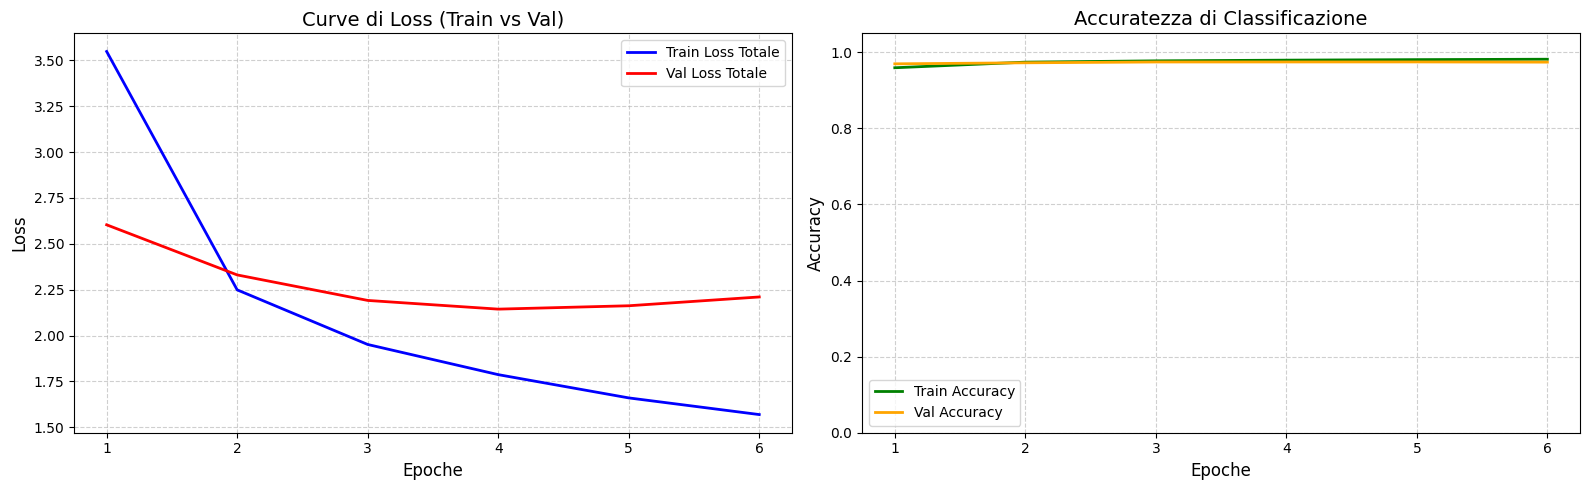

In [11]:
plot_history(b_conc_history)

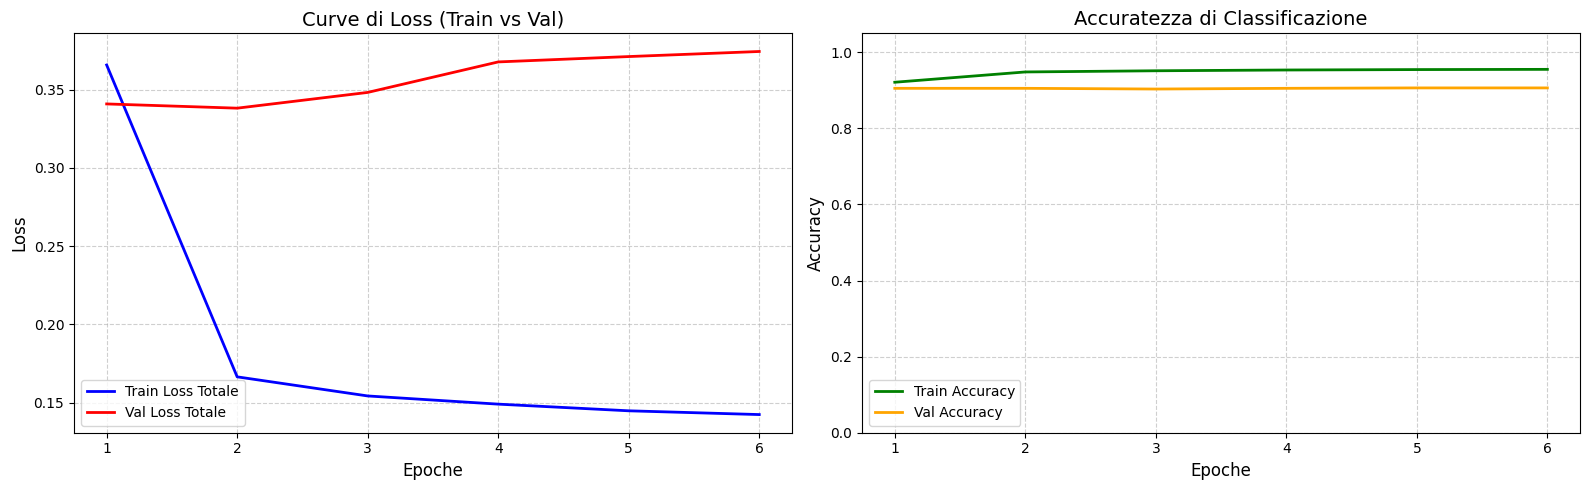

In [12]:
plot_history(b_cls_history)

#### Test

In [13]:
accuracy, preds, labels, b_conc_preds, b_conc_true, b_conc_probs = test_sequential_cbm(
    b_cls,
    b_concept_predictor,
    test_dataloader,
    box_tensors,
    class_concept_matrix,
    device,
    info,
)

Inizio valutazione sul Test Set (Modalità Sequenziale)...

Risultati Test Set (Sequenziale):
Accuratezza Totale: 90.46% (6753/7465)

Classification Report (prime 10 classi):
              precision    recall  f1-score   support

           0       0.76      0.94      0.84       209
           1       0.89      0.96      0.92       170
           2       0.85      0.88      0.86        58
           3       0.75      0.79      0.77        38
           4       0.96      0.98      0.97       110
           5       0.94      0.89      0.92       149
           6       0.92      0.94      0.93       329
           7       0.85      0.90      0.88       207
           8       0.67      0.11      0.20        35
           9       0.67      0.90      0.77       100

   micro avg       0.85      0.91      0.88      1405
   macro avg       0.83      0.83      0.81      1405
weighted avg       0.86      0.91      0.87      1405



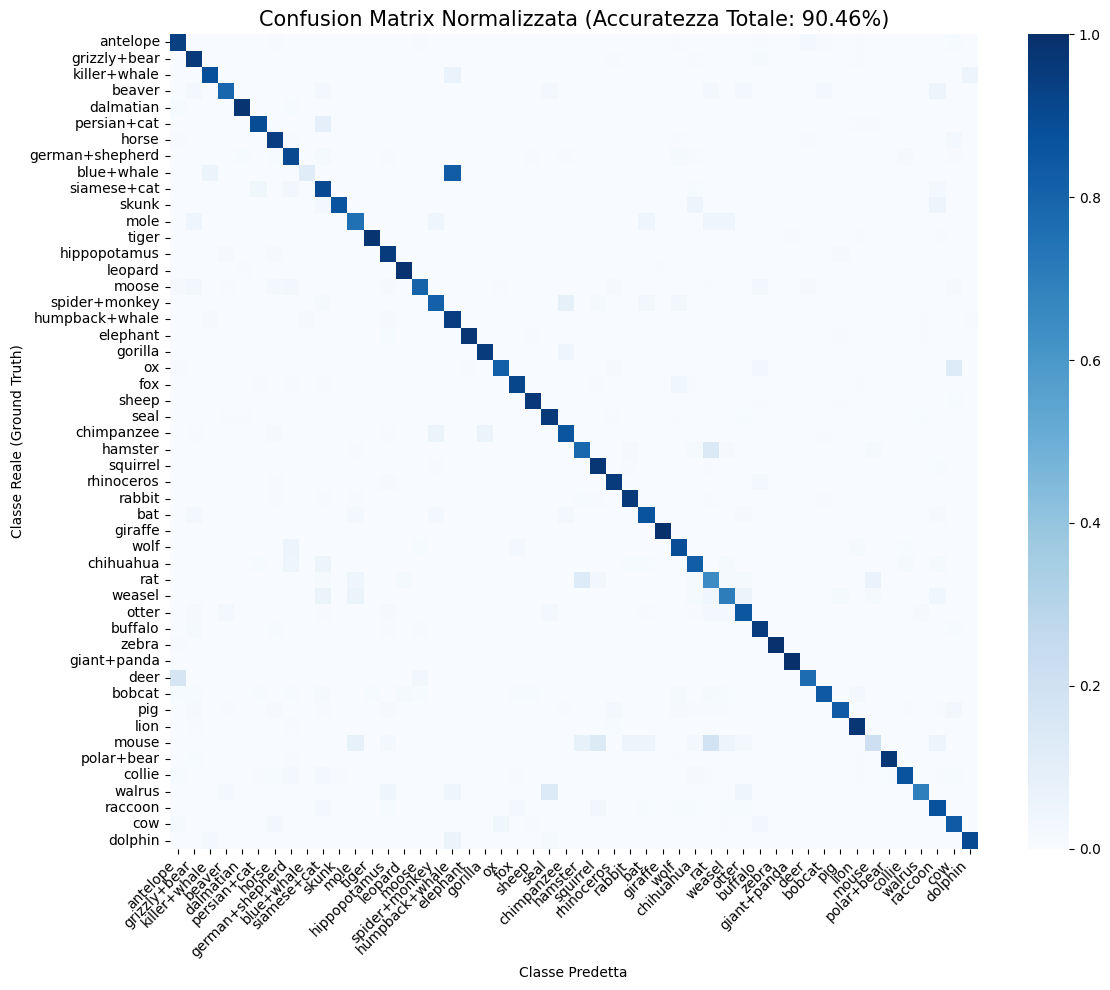


Analisi degli Errori Principali:
 - 46 volte: 'deer' è stato scambiato per 'antelope'
 - 29 volte: 'blue+whale' è stato scambiato per 'humpback+whale'
 - 22 volte: 'hamster' è stato scambiato per 'rat'
 - 19 volte: 'ox' è stato scambiato per 'cow'
 - 14 volte: 'persian+cat' è stato scambiato per 'siamese+cat'


In [18]:
plot_test_results(accuracy, preds, labels, class_names=classes)

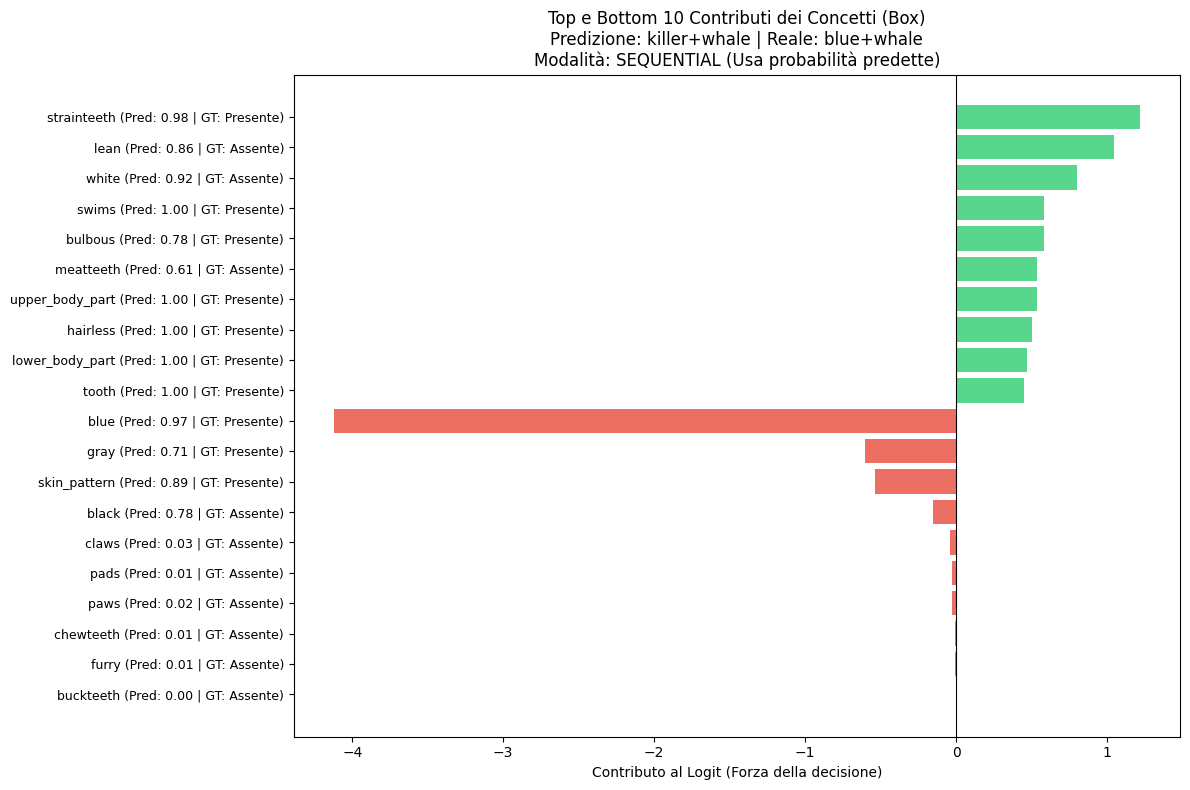

False

In [29]:
from src.CHM.interpretation import explain_prediction

explain_prediction(
    b_cls, 
    test_dataloader, 
    concepts, 
    classes, 
    class_concept_matrix, 
    box_tensors,
    concept_predictor=b_concept_predictor,
    target_class="blue+whale"
)

### CBM with cond prob distrib

#### Train

In [30]:
info = "rel_matrix"
bipolar = True
cp_cls = ConceptBottleneckClassifier(box_dim=box_tensors.size(-1), num_classes=NUM_CLASSES, num_concepts=NUM_CONCEPTS, info=info)
cp_optimizer = torch.optim.Adam(cp_cls.parameters(), lr=0.001)
cp_criterion = nn.CrossEntropyLoss()

cp_concept_predictor = ConceptPredictor(X_train.shape[1], num_concepts=NUM_CONCEPTS)
cp_concept_optimizer = torch.optim.Adam(cp_concept_predictor.parameters(), lr=0.001)
cp_concept_criterion = nn.BCEWithLogitsLoss()

cp_conc_history, cp_cls_history = sequential_training(
    cp_cls,
    cp_concept_predictor,
    train_dataloader, 
    val_dataloader,
    class_concept_matrix,
    box_tensors,
    cp_optimizer,  
    cp_concept_optimizer,
    cp_criterion,
    cp_concept_criterion,
    EPOCHS, 
    device,
    info,
    bipolar=False,
)

========== FASE 1: Addestramento Predittore Concetti (h -> c) ==========
Loss: 3.5643 | Acc: 95.9388 || Val Loss: 2.5902 | Val Acc: 96.9971
Loss: 2.2502 | Acc: 97.4270 || Val Loss: 2.3229 | Val Acc: 97.2928
Loss: 1.9566 | Acc: 97.7490 || Val Loss: 2.2240 | Val Acc: 97.4107
Loss: 1.7834 | Acc: 97.9464 || Val Loss: 2.1836 | Val Acc: 97.4492
Loss: 1.6616 | Acc: 98.0775 || Val Loss: 2.1395 | Val Acc: 97.5007
Loss: 1.5734 | Acc: 98.1742 || Val Loss: 2.1142 | Val Acc: 97.5366

========== FASE 2: Addestramento Classificatore Sequenziale (c_pred -> y) ==========
Epoca   1/6 | TRAIN: Loss=0.669, Acc=89.1% | VAL: Loss=0.384, Acc=90.4%
Epoca   2/6 | TRAIN: Loss=0.202, Acc=94.8% | VAL: Loss=0.335, Acc=90.7%
Epoca   3/6 | TRAIN: Loss=0.168, Acc=95.1% | VAL: Loss=0.331, Acc=90.5%
Epoca   4/6 | TRAIN: Loss=0.155, Acc=95.3% | VAL: Loss=0.322, Acc=90.6%
Epoca   5/6 | TRAIN: Loss=0.146, Acc=95.5% | VAL: Loss=0.328, Acc=90.7%
Epoca   6/6 | TRAIN: Loss=0.141, Acc=95.5% | VAL: Loss=0.326, Acc=90.8%

Addest

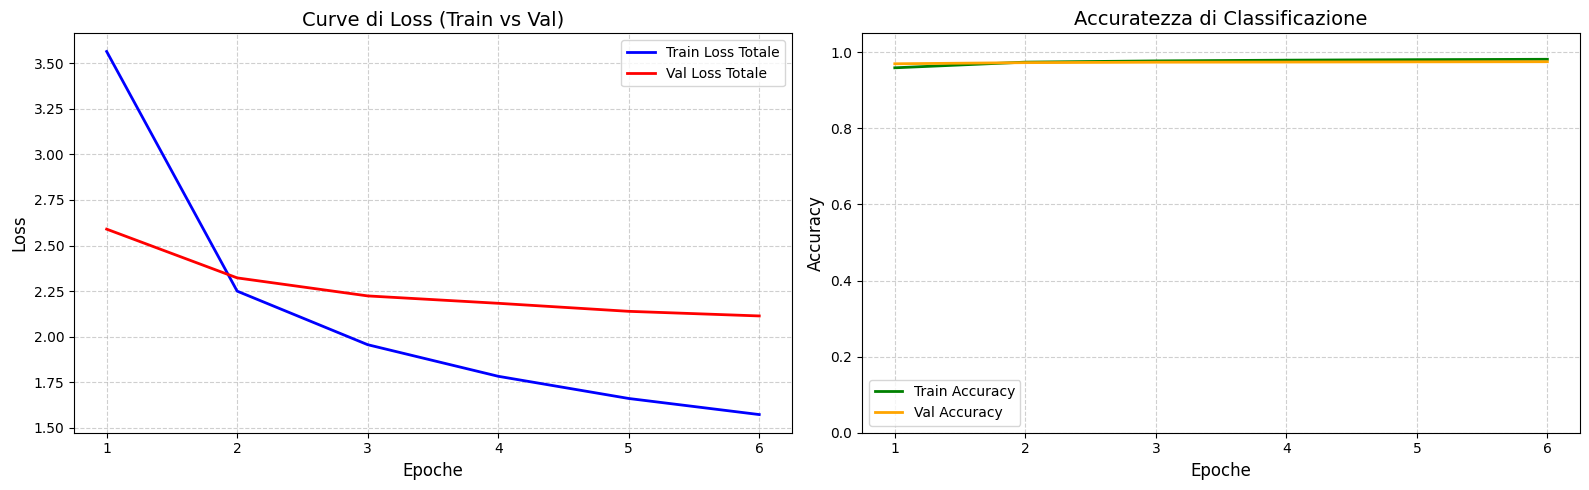

In [31]:
plot_history(cp_conc_history)

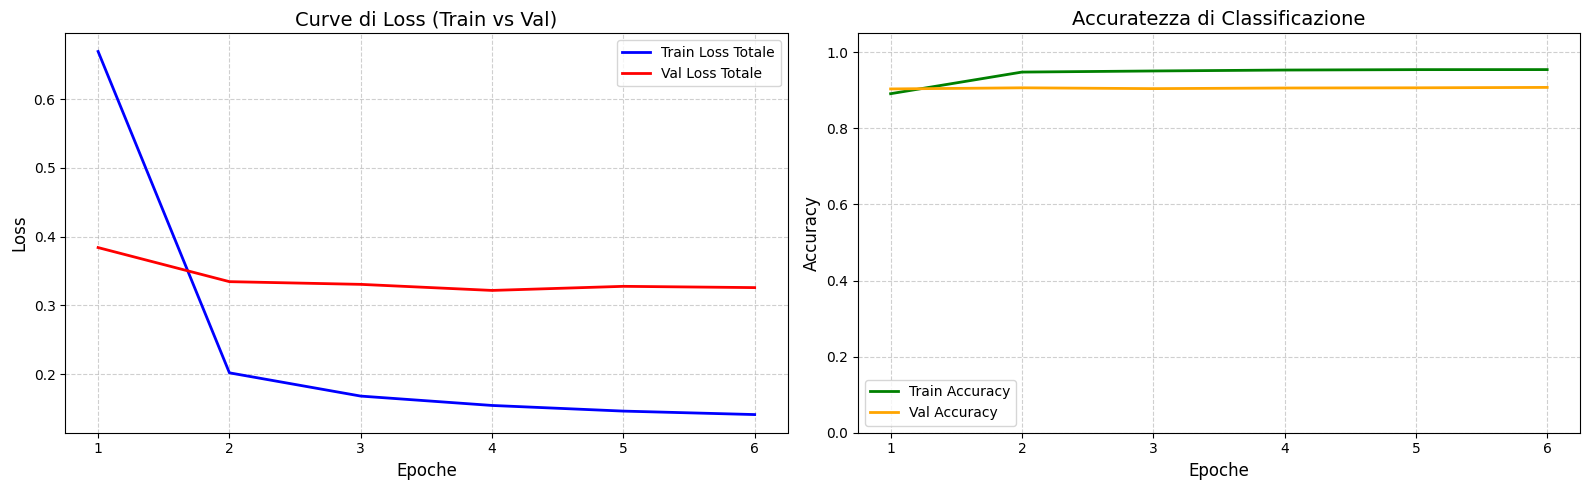

In [32]:
plot_history(cp_cls_history)

#### Test

In [33]:
cp_accuracy, cp_preds, cp_labels, cp_conc_preds, cp_conc_true, cp_conc_probs = test_sequential_cbm(
    cp_cls,
    cp_concept_predictor,
    test_dataloader,
    box_tensors,
    class_concept_matrix,
    device,
    info,
)

Inizio valutazione sul Test Set (Modalità Sequenziale)...

Risultati Test Set (Sequenziale):
Accuratezza Totale: 90.73% (6773/7465)

Classification Report (prime 10 classi):
              precision    recall  f1-score   support

           0       0.90      0.89      0.89       209
           1       0.89      0.95      0.92       170
           2       0.84      0.79      0.81        58
           3       0.71      0.76      0.73        38
           4       0.96      0.98      0.97       110
           5       0.91      0.97      0.94       149
           6       0.94      0.94      0.94       329
           7       0.91      0.86      0.88       207
           8       0.33      0.06      0.10        35
           9       0.80      0.87      0.83       100

   micro avg       0.90      0.89      0.89      1405
   macro avg       0.82      0.81      0.80      1405
weighted avg       0.89      0.89      0.88      1405



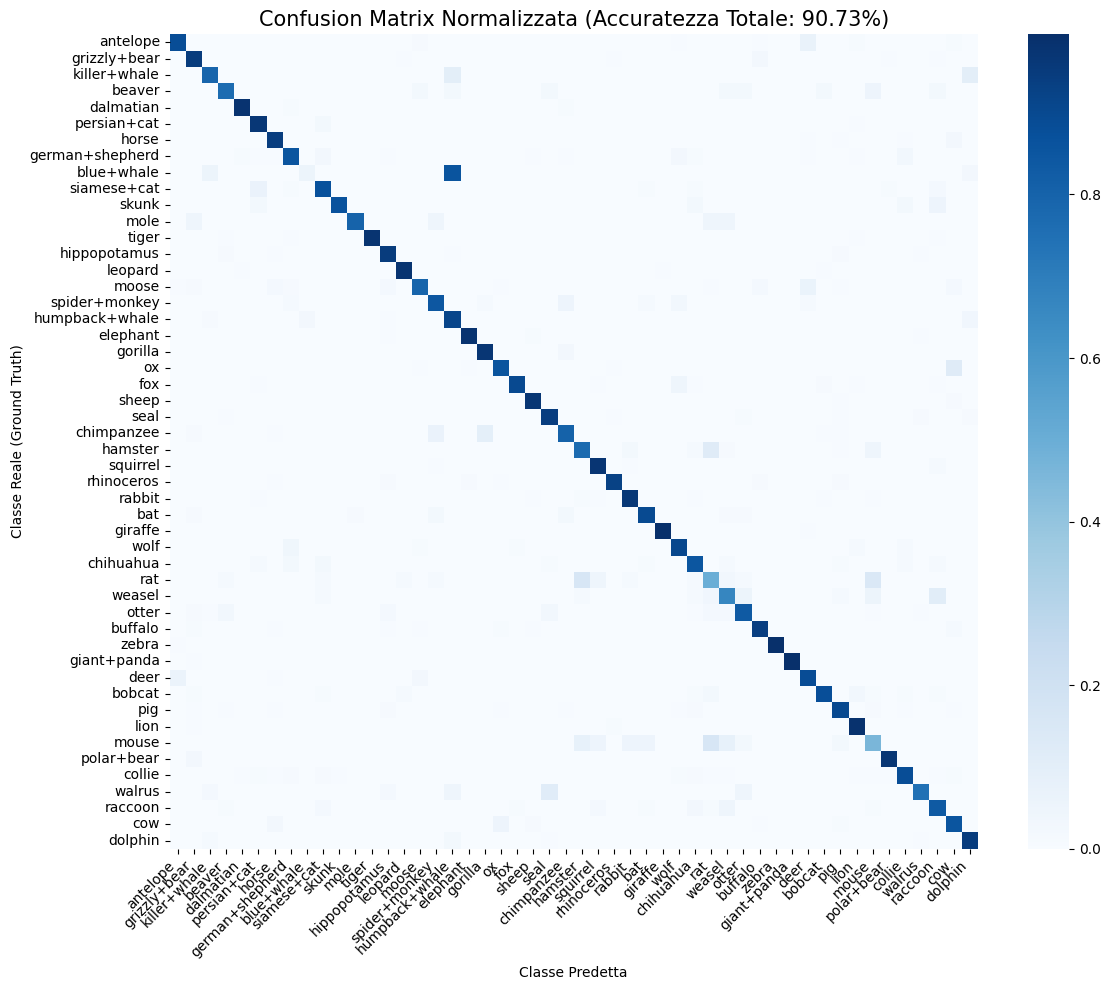


Analisi degli Errori Principali:
 - 30 volte: 'blue+whale' è stato scambiato per 'humpback+whale'
 - 19 volte: 'hamster' è stato scambiato per 'rat'
 - 18 volte: 'ox' è stato scambiato per 'cow'
 - 16 volte: 'deer' è stato scambiato per 'antelope'
 - 15 volte: 'antelope' è stato scambiato per 'deer'


In [34]:
plot_test_results(cp_accuracy, cp_preds, cp_labels, class_names=classes)

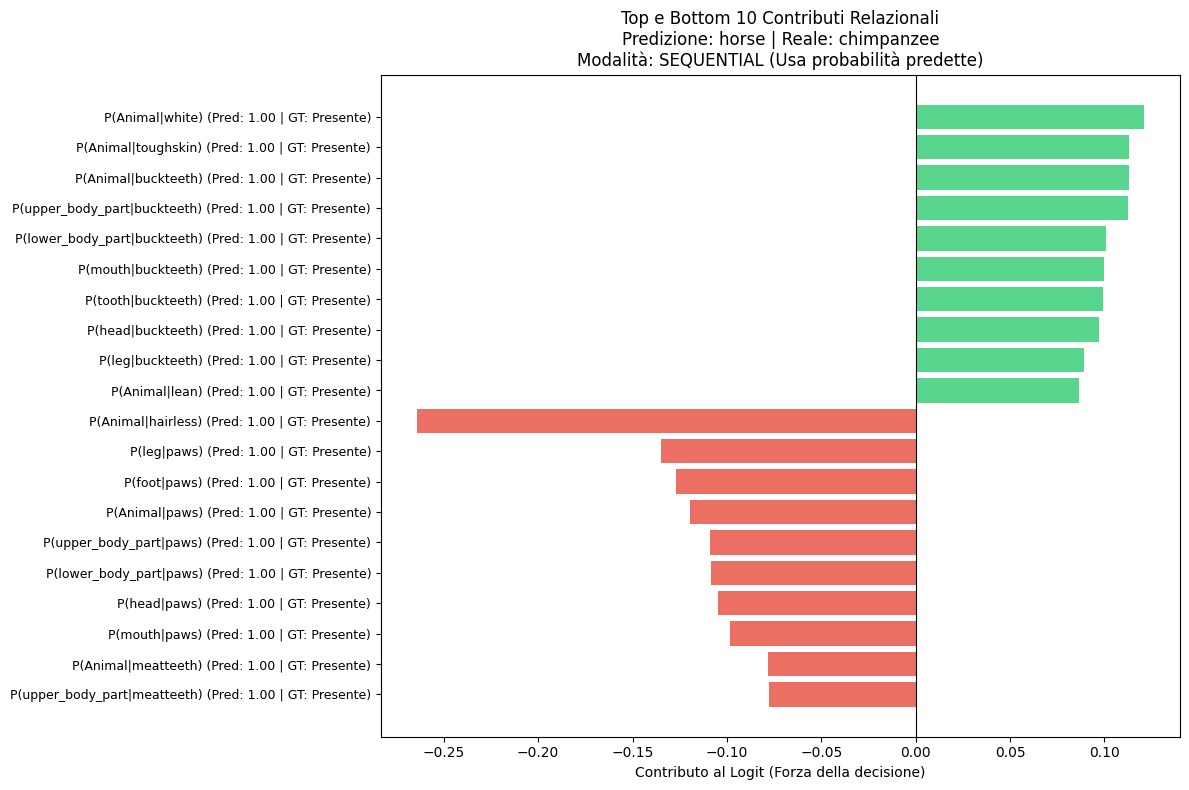

False

In [35]:
from src.CHM.interpretation import explain_prediction

explain_prediction(
    cp_cls, 
    test_dataloader, 
    concepts, 
    classes, 
    class_concept_matrix, 
    box_tensors,
    concept_predictor=cp_concept_predictor,
    target_class="chimpanzee",
    info_type=info,
)

### CBM standard

In [36]:
info = "concepts"
c_cls = ConceptBottleneckClassifier(box_dim=box_tensors.size(-1), num_classes=NUM_CLASSES, num_concepts=NUM_CONCEPTS, info=info)
c_optimizer = torch.optim.Adam(c_cls.parameters(), lr=0.001)
c_criterion = nn.CrossEntropyLoss()


c_concept_predictor = ConceptPredictor(X_train.shape[1], num_concepts=NUM_CONCEPTS)
c_concept_optimizer = torch.optim.Adam(c_concept_predictor.parameters(), lr=0.001)
c_concept_criterion = nn.BCEWithLogitsLoss()

c_conc_history, c_cls_history = sequential_training(
    c_cls,
    c_concept_predictor,
    train_dataloader, 
    val_dataloader,
    class_concept_matrix,
    box_tensors,
    c_optimizer,  
    c_concept_optimizer,
    c_criterion,
    c_concept_criterion,
    EPOCHS, 
    device,
    info,
    bipolar=False,
)

========== FASE 1: Addestramento Predittore Concetti (h -> c) ==========
Loss: 3.5620 | Acc: 95.9402 || Val Loss: 2.6316 | Val Acc: 96.9810
Loss: 2.2638 | Acc: 97.4181 || Val Loss: 2.3329 | Val Acc: 97.2794
Loss: 1.9563 | Acc: 97.7501 || Val Loss: 2.1924 | Val Acc: 97.4648
Loss: 1.7891 | Acc: 97.9358 || Val Loss: 2.1458 | Val Acc: 97.4916
Loss: 1.6622 | Acc: 98.0893 || Val Loss: 2.1429 | Val Acc: 97.4958
Loss: 1.5691 | Acc: 98.1854 || Val Loss: 2.1650 | Val Acc: 97.4921

========== FASE 2: Addestramento Classificatore Sequenziale (c_pred -> y) ==========
Epoca   1/6 | TRAIN: Loss=1.865, Acc=72.1% | VAL: Loss=0.956, Acc=87.2%
Epoca   2/6 | TRAIN: Loss=0.601, Acc=92.5% | VAL: Loss=0.548, Acc=89.4%
Epoca   3/6 | TRAIN: Loss=0.362, Acc=93.8% | VAL: Loss=0.429, Acc=90.1%
Epoca   4/6 | TRAIN: Loss=0.274, Acc=94.4% | VAL: Loss=0.376, Acc=90.4%
Epoca   5/6 | TRAIN: Loss=0.230, Acc=94.7% | VAL: Loss=0.349, Acc=90.6%
Epoca   6/6 | TRAIN: Loss=0.204, Acc=94.9% | VAL: Loss=0.334, Acc=90.7%

Addest

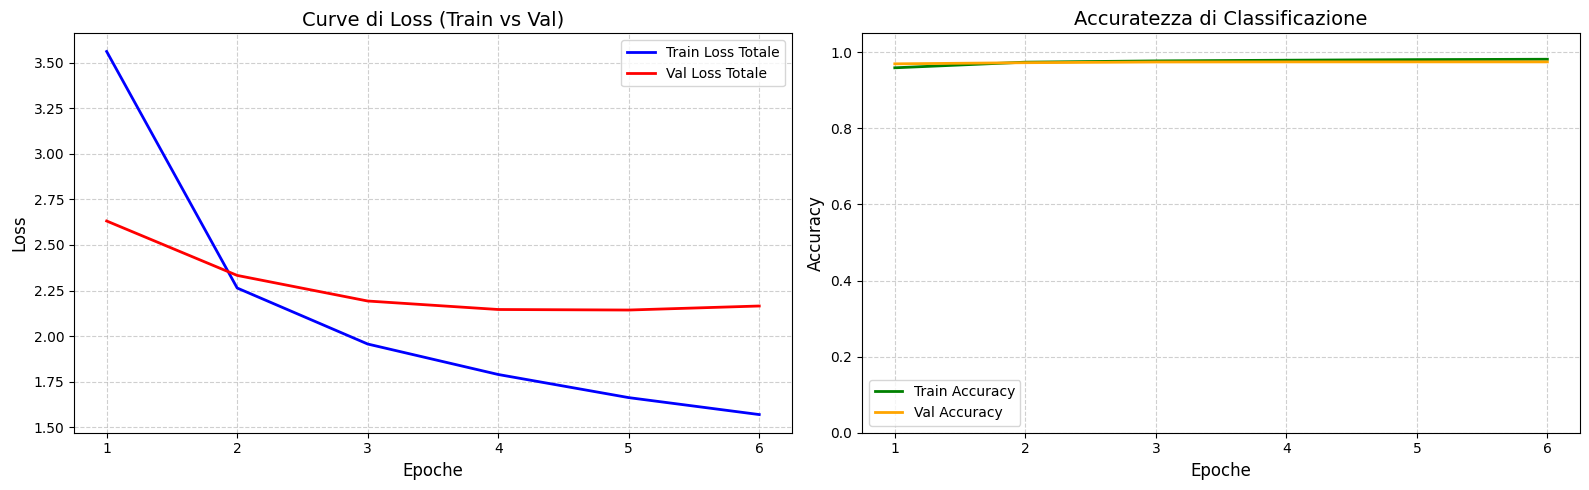

In [37]:
from src.utils.plot import plot_history
plot_history(c_conc_history)

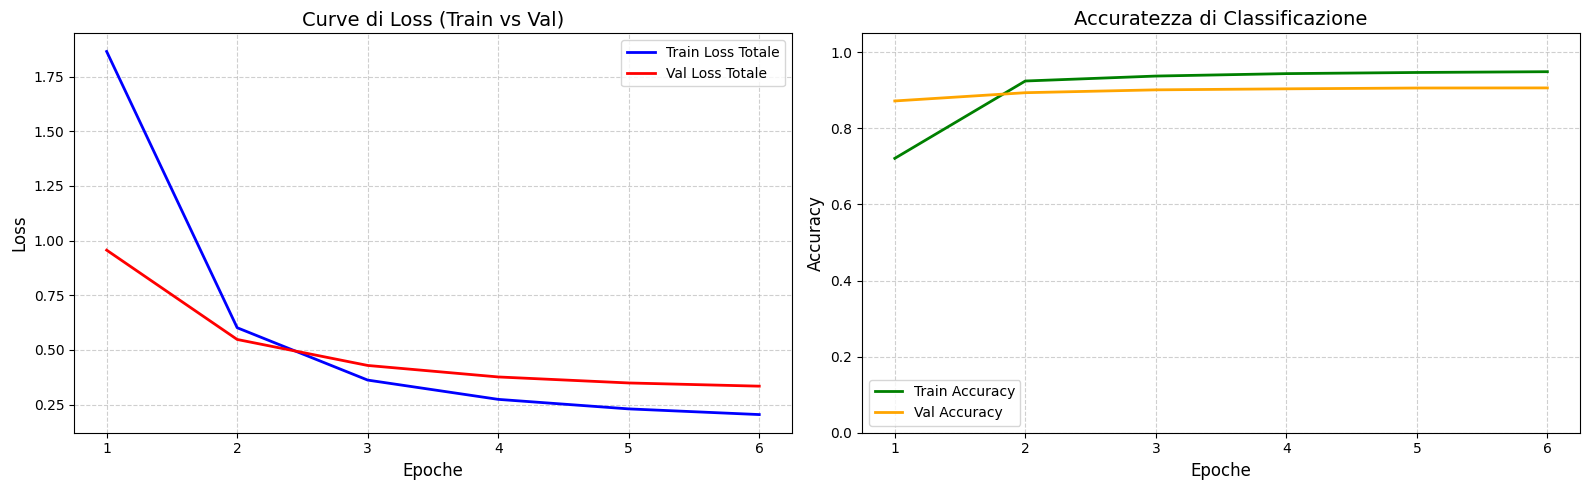

In [38]:
plot_history(c_cls_history)

In [39]:
c_accuracy, c_preds, c_labels, c_conc_preds, c_conc_true, c_conc_probs = test_sequential_cbm(
    c_cls,
    c_concept_predictor,
    test_dataloader,
    box_tensors,
    class_concept_matrix,
    device,
    info,
)

Inizio valutazione sul Test Set (Modalità Sequenziale)...

Risultati Test Set (Sequenziale):
Accuratezza Totale: 91.12% (6802/7465)

Classification Report (prime 10 classi):
              precision    recall  f1-score   support

           0       0.92      0.89      0.91       209
           1       0.89      0.94      0.91       170
           2       0.90      0.81      0.85        58
           3       0.82      0.71      0.76        38
           4       0.96      0.99      0.98       110
           5       0.92      0.95      0.93       149
           6       0.94      0.93      0.94       329
           7       0.89      0.88      0.89       207
           8       0.50      0.03      0.05        35
           9       0.88      0.86      0.87       100

   micro avg       0.91      0.89      0.90      1405
   macro avg       0.86      0.80      0.81      1405
weighted avg       0.90      0.89      0.89      1405



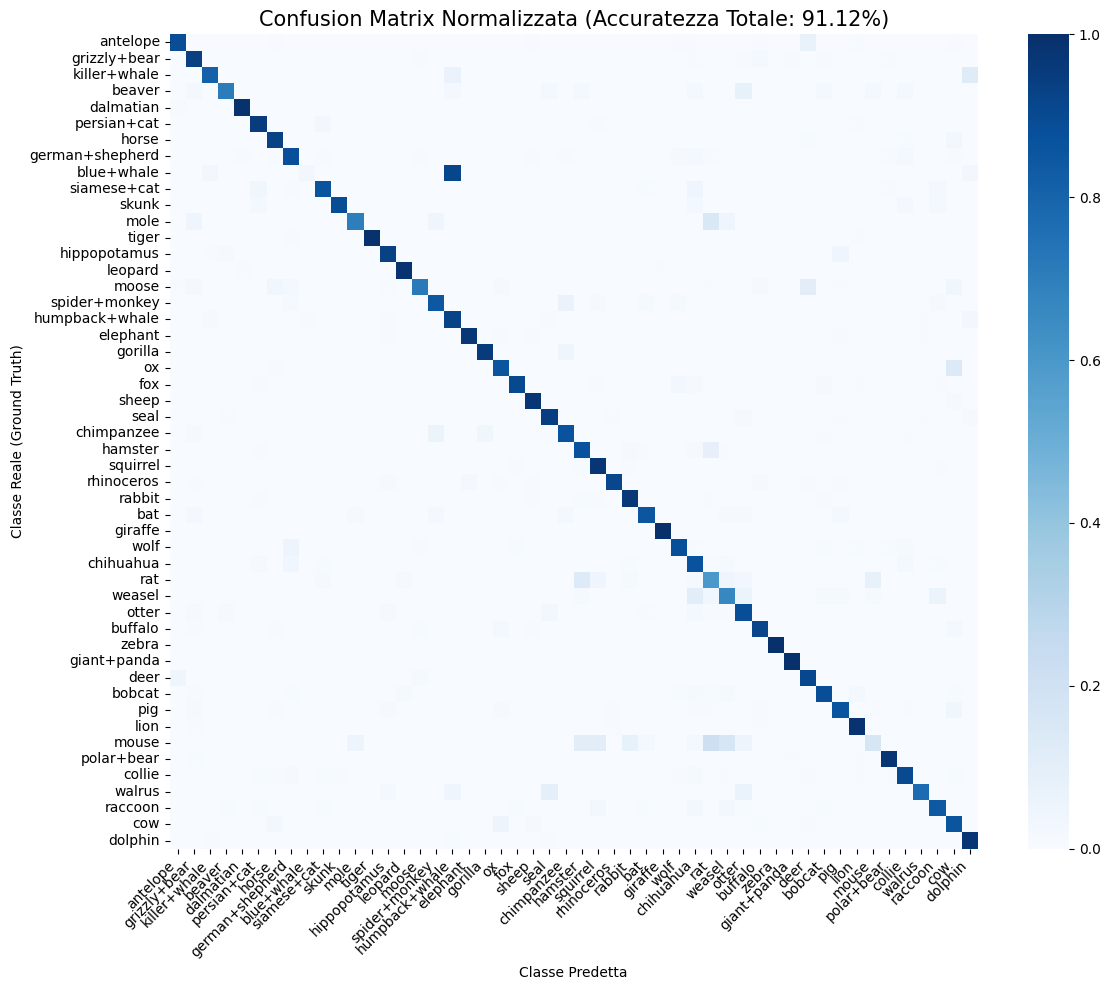


Analisi degli Errori Principali:
 - 32 volte: 'blue+whale' è stato scambiato per 'humpback+whale'
 - 20 volte: 'ox' è stato scambiato per 'cow'
 - 15 volte: 'moose' è stato scambiato per 'deer'
 - 15 volte: 'antelope' è stato scambiato per 'deer'
 - 14 volte: 'cow' è stato scambiato per 'ox'


In [40]:
plot_test_results(c_accuracy, c_preds, c_labels, class_names=classes)

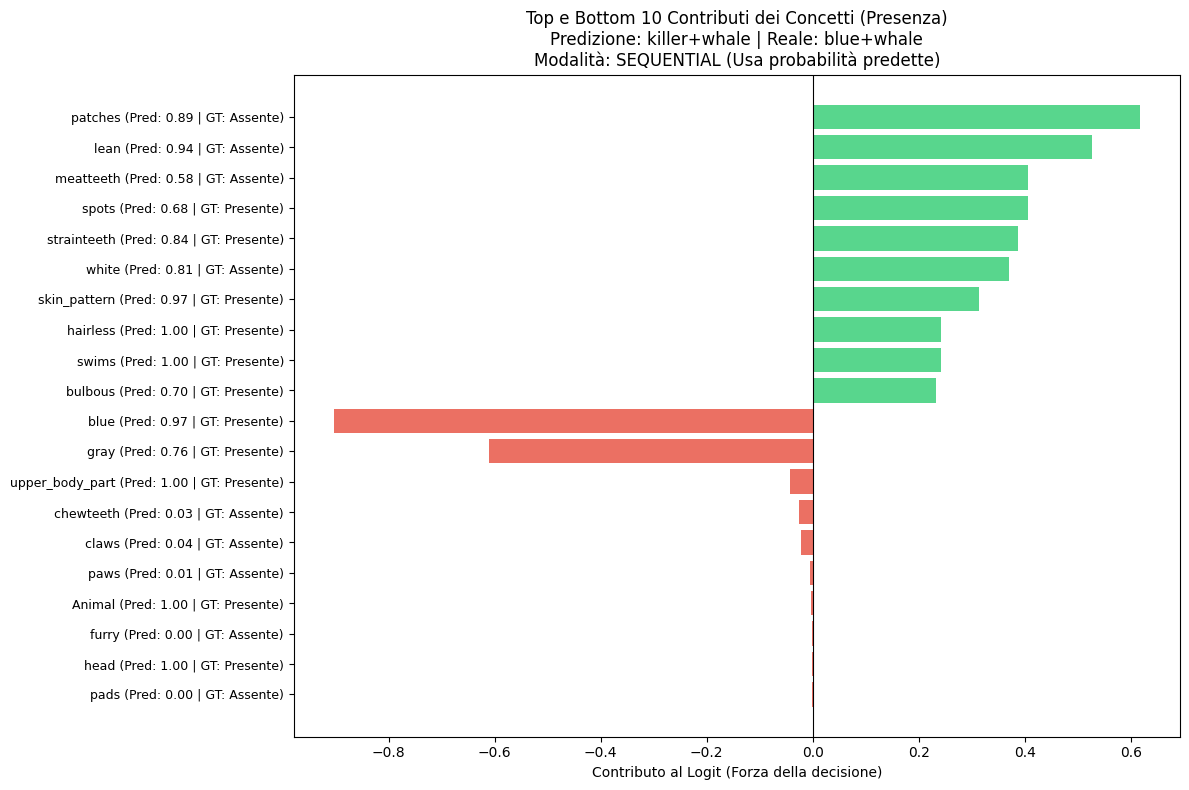

False

In [44]:
from src.CHM.interpretation import explain_prediction

explain_prediction(
    c_cls, 
    test_dataloader, 
    concepts, 
    classes, 
    class_concept_matrix, 
    box_tensors,
    concept_predictor=c_concept_predictor,
    target_class="blue+whale",
    info_type=info,
)

### CBM ALL

#### Train

In [40]:
info = "all"
bipolar = True
a_cls = ConceptBottleneckClassifier(box_dim=box_tensors.size(-1), num_classes=NUM_CLASSES, num_concepts=NUM_CONCEPTS, info=info)
a_optimizer = torch.optim.Adam(a_cls.parameters(), lr=0.001)
a_criterion = nn.CrossEntropyLoss()

a_concept_predictor = ConceptPredictor(X_train.shape[1], num_concepts=NUM_CONCEPTS)
a_concept_optimizer = torch.optim.Adam(a_concept_predictor.parameters(), lr=0.001)
a_concept_criterion = nn.BCEWithLogitsLoss()

a_conc_history, a_cls_history = sequential_training(
    a_cls,
    a_concept_predictor,
    train_dataloader, 
    val_dataloader,
    class_concept_matrix,
    box_tensors,
    a_optimizer,  
    a_concept_optimizer,
    a_criterion,
    a_concept_criterion,
    EPOCHS, 
    device,
    info,
    bipolar=False,
)

========== FASE 1: Addestramento Predittore Concetti (h -> c) ==========
Loss: 3.3757 | Acc: 96.1723 || Val Loss: 2.4228 | Val Acc: 97.1965
Loss: 2.0926 | Acc: 97.6025 || Val Loss: 2.1647 | Val Acc: 97.4990
Loss: 1.8175 | Acc: 97.9290 || Val Loss: 2.0916 | Val Acc: 97.5871
Loss: 1.6536 | Acc: 98.0960 || Val Loss: 2.0226 | Val Acc: 97.6568
Loss: 1.5324 | Acc: 98.2371 || Val Loss: 1.9901 | Val Acc: 97.6719
Loss: 1.4508 | Acc: 98.3269 || Val Loss: 2.0069 | Val Acc: 97.6558
Loss: 1.3740 | Acc: 98.4260 || Val Loss: 1.9789 | Val Acc: 97.7274
Loss: 1.3138 | Acc: 98.4847 || Val Loss: 2.0038 | Val Acc: 97.7060
Loss: 1.2750 | Acc: 98.5327 || Val Loss: 2.0449 | Val Acc: 97.6514
Loss: 1.2309 | Acc: 98.5736 || Val Loss: 2.0267 | Val Acc: 97.6875
Loss: 1.1950 | Acc: 98.6243 || Val Loss: 2.0574 | Val Acc: 97.6938
Loss: 1.1526 | Acc: 98.6726 || Val Loss: 2.0741 | Val Acc: 97.6524
Loss: 1.1339 | Acc: 98.6955 || Val Loss: 2.0725 | Val Acc: 97.6977
Loss: 1.1064 | Acc: 98.7235 || Val Loss: 2.1321 | Val Ac

#### Test

In [41]:
a_accuracy, a_preds, a_labels = test_sequential_cbm(
    a_cls,
    a_concept_predictor,
    test_dataloader,
    box_tensors,
    class_concept_matrix,
    device,
    info,
)

Inizio valutazione sul Test Set (Modalità Sequenziale)...

Risultati Test Set (Sequenziale):
Accuratezza Totale: 89.56% (6686/7465)

Classification Report (prime 10 classi):
              precision    recall  f1-score   support

           0       0.89      0.89      0.89       209
           1       0.85      0.94      0.89       170
           2       0.76      0.88      0.82        58
           3       0.68      0.71      0.69        38
           4       0.96      0.98      0.97       110
           5       0.95      0.90      0.92       149
           6       0.94      0.94      0.94       329
           7       0.87      0.82      0.84       207
           8       0.35      0.31      0.33        35
           9       0.72      0.88      0.79       100

   micro avg       0.87      0.88      0.88      1405
   macro avg       0.80      0.83      0.81      1405
weighted avg       0.87      0.88      0.88      1405

